# Step 9: Build the Transport Model in AequilibraE

**Kandy District LUTI Model — Baseline Transport Network**

This notebook builds a fully calibrated baseline transport model for Kandy District using AequilibraE 1.6.2.

## What this notebook does
1. Creates a fresh AequilibraE project
2. Imports the road network from the local shapefile (no OSM download needed)
3. Imports Traffic Analysis Zones (TAZ) and centroids via fast bulk SQL
4. Creates centroid connectors
5. Runs free-flow network skimming to get a travel-time matrix
6. Builds an OD demand matrix using a gravity model calibrated on census data
7. Runs Frank-Wolfe traffic assignment
8. Exports results (skim matrix, link loads, convergence report)
9. Performs calibration check against observed counts

## Key design: Fast bulk import
All network, zone, and centroid data are inserted via bulk SQL (triggers removed during import).
This replaces the slow one-by-one Python API calls that caused the 1+ hour runtimes.

**Expected runtime:** 15–30 minutes (dominated by connector creation and assignment)

In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Imports
# ══════════════════════════════════════════════════════════════
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from aequilibrae import Project, AequilibraeMatrix
from aequilibrae.distribution import GravityApplication, SyntheticGravityModel
from aequilibrae.paths import TrafficAssignment, TrafficClass
from aequilibrae.paths.network_skimming import NetworkSkimming
from aequilibrae.project.project_creation import remove_triggers, add_triggers
from aequilibrae.utils.db_utils import commit_and_close

warnings.filterwarnings('ignore', category=UserWarning)
print('All imports OK')

All imports OK


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Path configuration
# ══════════════════════════════════════════════════════════════
# Root of your LUTI workspace (the folder you selected in Cowork)
BASE_DIR = Path(r'E:\LUTI Research\kandy_luti')

# Input data paths
ROAD_SHP    = BASE_DIR / 'data' / 'transport' / 'Kandy_Road_Network_Final.shp'
TAZ_SHP     = BASE_DIR / 'data' / 'transport' / 'Kandy_TAZ_System.shp'
CENSUS_CSV  = BASE_DIR / 'data' / 'census'    / 'Kandy_TAZ_SocioEconomic.csv'
COUNTS_CSV  = BASE_DIR / 'data' / 'transport' / 'calibration_counts.csv'

# Output project path (will be created fresh each run)
PROJECT_PATH = BASE_DIR / 'transport' / 'baseline' / 'aeq_project'
RESULTS_DIR  = BASE_DIR / 'transport' / 'baseline'

# Verify inputs exist
for p in [ROAD_SHP, TAZ_SHP, CENSUS_CSV, COUNTS_CSV]:
    status = '✓' if p.exists() else '✗ MISSING'
    print(f'{status}  {p.name}')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('\nOutput directory:', RESULTS_DIR)

✓  Kandy_Road_Network_Final.shp
✓  Kandy_TAZ_System.shp
✓  Kandy_TAZ_SocioEconomic.csv
✓  calibration_counts.csv

Output directory: E:\LUTI Research\kandy_luti\transport\baseline


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Create AequilibraE project
# ══════════════════════════════════════════════════════════════
# Delete any existing project so we start fresh
if PROJECT_PATH.exists():
    shutil.rmtree(PROJECT_PATH)
    print('Removed existing project')

project = Project()
project.new(str(PROJECT_PATH))
print('Created new project at:', PROJECT_PATH)

# Database path (used for bulk SQL later)
DB_PATH = str(PROJECT_PATH / 'project_database.sqlite')

No pre-existing parameter file exists for this project. Will use default
No pre-existing parameter file exists for this project. Will use default


Removed existing project
Created new project at: E:\LUTI Research\kandy_luti\transport\baseline\aeq_project


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Add custom link types
# ══════════════════════════════════════════════════════════════
# The link_types table needs entries matching the road_class values
# in the road shapefile: Arterial, Collector, Local, Other
#
# Default entries (centroid_connector 'z', default 'y') already exist.
# We add our road-specific types.

link_types_to_add = [
    # (link_type,   link_type_id, description,             lanes, lane_capacity, speed_kmh)
    ('Arterial',   'a',          'Main arterial roads',       2,    1800,          60),
    ('Collector',  'c',          'Collector distributor roads',2,   1200,          40),
    ('Local',      'l',          'Local access roads',        2,     800,          30),
    ('Other',      'o',          'Other/unclassified roads',  1,     600,          20),
]

with project.db_connection as conn:
    conn.executemany(
        """INSERT OR IGNORE INTO link_types
           (link_type, link_type_id, description, lanes, lane_capacity, speed)
           VALUES (?,?,?,?,?,?)""",
        link_types_to_add
    )

# Verify
with project.db_connection as conn:
    lt = pd.read_sql('SELECT link_type, link_type_id, lanes FROM link_types', conn)
print('Link types in database:')
print(lt.to_string(index=False))

Link types in database:
         link_type link_type_id  lanes
centroid_connector            z     10
           default            y      2
          Arterial            a      2
         Collector            c      2
             Local            l      2
             Other            o      1


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Import road network from shapefile (FAST bulk method)
# ══════════════════════════════════════════════════════════════
# Strategy:
#   1. Read + explode + reproject to WGS84
#   2. Extract unique nodes from link endpoints
#   3. REMOVE all triggers (eliminates per-row spatial queries)
#   4. Bulk-insert nodes with MakePoint()
#   5. Bulk-insert links with GeomFromText() and pre-computed a_node/b_node
#   6. RE-ADD triggers (for future interactive edits)
#   7. Update node modes/link_types via single SQL pass

print('Reading road network shapefile...')
road = gpd.read_file(str(ROAD_SHP))
print(f'  Raw links: {len(road):,}  |  CRS: {road.crs}')

# ── Explode MultiLineString → LineString ──
road = road.explode(index_parts=False).reset_index(drop=True)
print(f'  After explode: {len(road):,} links')

# ── Reproject to WGS84 (EPSG:4326) — required by AequilibraE ──
road_wgs = road.to_crs(epsg=4326)

# ── Direction: oneway='yes' → direction=1 (A→B only), else 0 ──
road_wgs = road_wgs.copy()
road_wgs['direction'] = (road_wgs['oneway'] == 'yes').astype(int)

# ── Speeds and travel times ──
road_wgs['speed_ab'] = road_wgs['speed_kph'].fillna(30.0).astype(float)
road_wgs['speed_ba'] = road_wgs['speed_ab']
# travel_time in minutes: distance_km / speed_kph * 60
road_wgs['travel_time_ab'] = (road_wgs['length_m'] / 1000.0) / road_wgs['speed_ab'] * 60.0
road_wgs['travel_time_ba'] = road_wgs['travel_time_ab']  # default both directions
# For oneway links: BA travel time → very high (effectively blocked in assignment)
oneway_mask = road_wgs['direction'] == 1
road_wgs.loc[oneway_mask, 'travel_time_ba'] = 9999.0

# ── Capacities ──
road_wgs['capacity_ab'] = road_wgs['capacity_p'].fillna(800.0).astype(float)
road_wgs['capacity_ba'] = road_wgs['capacity_ab']
road_wgs.loc[oneway_mask, 'capacity_ba'] = 0.001  # Near-zero (avoid div/0 in BPR)

# ── Link type and modes ──
road_wgs['link_type_aeq'] = road_wgs['road_class'].fillna('Other').astype(str)
road_wgs.loc[~road_wgs['link_type_aeq'].isin(['Arterial','Collector','Local','Other']),
              'link_type_aeq'] = 'Other'
road_wgs['modes'] = 'c'  # All roads allow car travel

# ── Link name (handle NaN) ──
road_wgs['link_name'] = road_wgs['name'].fillna('').astype(str).str[:50]

# ── Extract unique nodes from link endpoints ──
# Node IDs start at 10001 to leave room for zone centroids (1..1187)
COORD_PREC = 4   # 7 decimal places ≈ 1 cm precision in WGS84
NODE_ID_START = 10001

coords_to_nid = {}  # (rounded_lon, rounded_lat) → node_id
nid_counter = NODE_ID_START
nodes_records = []  # (node_id, is_centroid, lon, lat)

for geom in road_wgs.geometry:
    for coord in [geom.coords[0], geom.coords[-1]]:
        key = (round(coord[0], COORD_PREC), round(coord[1], COORD_PREC))
        if key not in coords_to_nid:
            coords_to_nid[key] = nid_counter
            nodes_records.append((nid_counter, 0, key[0], key[1]))
            nid_counter += 1

print(f'  Unique network nodes: {len(nodes_records):,}')

# ── Assign a_node / b_node to each link ──
a_nodes, b_nodes = [], []
for geom in road_wgs.geometry:
    c0, c1 = geom.coords[0], geom.coords[-1]
    a_nodes.append(coords_to_nid[(round(c0[0], COORD_PREC), round(c0[1], COORD_PREC))])
    b_nodes.append(coords_to_nid[(round(c1[0], COORD_PREC), round(c1[1], COORD_PREC))])

road_wgs = road_wgs.copy()
road_wgs['a_node']  = a_nodes
road_wgs['b_node']  = b_nodes
road_wgs['link_id'] = np.arange(1, len(road_wgs) + 1, dtype=int)

# ── Build link records for executemany ──
wkt_list = road_wgs.geometry.apply(lambda g: g.wkt).tolist()

link_records = list(zip(
    road_wgs['link_id'].astype(int),
    road_wgs['a_node'].astype(int),
    road_wgs['b_node'].astype(int),
    road_wgs['direction'].astype(int),
    road_wgs['length_m'].astype(float),
    road_wgs['modes'],
    road_wgs['link_type_aeq'],
    road_wgs['link_name'],
    road_wgs['speed_ab'].astype(float),
    road_wgs['speed_ba'].astype(float),
    road_wgs['travel_time_ab'].astype(float),
    road_wgs['travel_time_ba'].astype(float),
    road_wgs['capacity_ab'].astype(float),
    road_wgs['capacity_ba'].astype(float),
    wkt_list,
))

# ── BULK INSERT into AequilibraE database ──
print('\nInserting into database...')

node_sql = (
    "INSERT INTO nodes (node_id, is_centroid, geometry) "
    "VALUES (?, ?, MakePoint(?, ?, 4326))"
)

link_sql = (
    "INSERT INTO links "
    "(link_id, a_node, b_node, direction, distance, modes, link_type, name, "
    " speed_ab, speed_ba, travel_time_ab, travel_time_ba, capacity_ab, capacity_ba, "
    " geometry) "
    "VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?, GeomFromText(?,4326))"
)

with commit_and_close(DB_PATH, spatial=True) as conn:
    # Remove all triggers — eliminates ~60k spatial queries during bulk insert
    remove_triggers(conn, project.logger, 'network')

    # Clear any existing nodes/links (makes cell safely re-runnable)
    conn.execute('DELETE FROM links')
    conn.execute('DELETE FROM nodes')
    conn.commit()

    # Insert nodes
    conn.executemany(node_sql, nodes_records)
    conn.commit()
    print(f'  ✓ Inserted {len(nodes_records):,} nodes')

    # Insert links
    conn.executemany(link_sql, link_records)
    conn.commit()
    print(f'  ✓ Inserted {len(link_records):,} links')

    # Update node modes: all road nodes → mode 'c'
    conn.execute("""
        UPDATE nodes SET modes = 'c'
        WHERE is_centroid = 0
        AND node_id IN (SELECT a_node FROM links UNION SELECT b_node FROM links)
    """)

    # Update node link_types based on connected links
    conn.execute("""
        UPDATE nodes SET link_types = (
            SELECT GROUP_CONCAT(DISTINCT lt.link_type_id)
            FROM link_types lt
            WHERE lt.link_type IN (
                SELECT DISTINCT l.link_type FROM links l
                WHERE l.a_node = nodes.node_id OR l.b_node = nodes.node_id
            )
        )
        WHERE is_centroid = 0
    """)
    conn.commit()

    # Re-add triggers for future interactive edits
    add_triggers(conn, project.logger, 'network')
    conn.commit()

print('\n✓ Road network imported successfully')

Reading road network shapefile...
  Raw links: 16,567  |  CRS: EPSG:5235
  After explode: 16,567 links
  Unique network nodes: 16,004

Inserting into database...
  ✓ Inserted 16,004 nodes
  ✓ Inserted 16,567 links

✓ Road network imported successfully


In [6]:
import sqlite3
import numpy as np
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from pathlib import Path

# Adjust this path if yours differs
AEQ_DIR = Path(r"E:\LUTI Research\kandy_luti\transport\baseline\aeq_project")

conn = sqlite3.connect(str(AEQ_DIR / "project_database.sqlite"))
cur = conn.cursor()

# Pull all links (exclude centroid connectors if you want road-only check)
cur.execute("SELECT a_node, b_node FROM links")
edges = cur.fetchall()
conn.close()

# Get total node count
all_nodes = set()
for a, b in edges:
    all_nodes.add(a)
    all_nodes.add(b)

node_ids  = sorted(all_nodes)
node_index = {nid: i for i, nid in enumerate(node_ids)}
N = len(node_ids)

rows = [node_index[a] for a, b in edges]
cols = [node_index[b] for a, b in edges]
data = [1] * len(edges)

graph = sp.csr_matrix((data, (rows, cols)), shape=(N, N))

n_components, labels = connected_components(graph, directed=False)
print(f"Total nodes:         {N}")
print(f"Total edges:         {len(edges)}")
print(f"Connected components: {n_components}")   # Target: 1

# Breakdown of component sizes
unique, counts = np.unique(labels, return_counts=True)
sizes = sorted(counts, reverse=True)
print(f"Largest component:   {sizes[0]} nodes")
if len(sizes) > 1:
    print(f"2nd largest:         {sizes[1]} nodes")
    print(f"Components with 1 node (isolated): {sum(1 for s in sizes if s == 1)}")

Total nodes:         16004
Total edges:         16567
Connected components: 1
Largest component:   16004 nodes


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Verify network import
# ══════════════════════════════════════════════════════════════
with project.db_connection as conn:
    n_nodes = conn.execute('SELECT COUNT(*) FROM nodes').fetchone()[0]
    n_links = conn.execute('SELECT COUNT(*) FROM links').fetchone()[0]
    null_anodes = conn.execute('SELECT COUNT(*) FROM links WHERE a_node IS NULL OR a_node = 0').fetchone()[0]
    null_bnodes = conn.execute('SELECT COUNT(*) FROM links WHERE b_node IS NULL OR b_node = 0').fetchone()[0]
    speed_check = conn.execute('SELECT COUNT(*) FROM links WHERE travel_time_ab <= 0').fetchone()[0]
    cap_check   = conn.execute('SELECT COUNT(*) FROM links WHERE capacity_ab <= 0').fetchone()[0]

print(f'Nodes in DB:             {n_nodes:,}')
print(f'Links in DB:             {n_links:,}')
print(f'Links with null a_node:  {null_anodes}')
print(f'Links with null b_node:  {null_bnodes}')
print(f'Links with zero TT_ab:   {speed_check}')
print(f'Links with zero cap_ab:  {cap_check}')

if null_anodes > 0 or null_bnodes > 0:
    raise RuntimeError('Some links have null a_node or b_node — check coordinate precision')
if speed_check > 0:
    raise RuntimeError('Some links have zero or negative travel time — check speed_kph')
print('\n✓ Network integrity check passed')

Nodes in DB:             16,004
Links in DB:             16,567
Links with null a_node:  0
Links with null b_node:  0
Links with zero TT_ab:   0
Links with zero cap_ab:  0

✓ Network integrity check passed


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Import TAZ zones (fast bulk SQL)
# ══════════════════════════════════════════════════════════════
# Zones are stored in EPSG:5235 — must reproject to WGS84 for AequilibraE

print('Reading TAZ shapefile...')
taz = gpd.read_file(str(TAZ_SHP))
print(f'  TAZ zones: {len(taz):,}  |  CRS: {taz.crs}')
print(f'  TAZ_ID range: {taz["TAZ_ID"].min()} – {taz["TAZ_ID"].max()}')
print(f'  Null TAZ_IDs: {taz["TAZ_ID"].isnull().sum()}')

# ── Reproject to WGS84 ──
taz_wgs = taz.to_crs(epsg=4326).copy()

# ── Compute centroids in WGS84 (used later for centroid nodes) ──
taz_wgs['centroid_wgs'] = taz_wgs.geometry.centroid

# ── Ensure every geometry is a valid MultiPolygon in Python ──
from shapely.geometry import MultiPolygon as ShpMultiPolygon

def to_valid_multipolygon(geom):
    geom = geom.buffer(0)
    if geom.geom_type == 'Polygon':
        return ShpMultiPolygon([geom])
    elif geom.geom_type == 'MultiPolygon':
        return geom
    else:
        polys = [g for g in geom.geoms if g.geom_type == 'Polygon']
        return ShpMultiPolygon(polys) if polys else None

taz_wgs = taz_wgs.copy()
taz_wgs['geometry'] = taz_wgs['geometry'].apply(to_valid_multipolygon)
taz_wgs = taz_wgs[taz_wgs['geometry'].notna() & ~taz_wgs['geometry'].is_empty]
print(f'  Valid MultiPolygon zones: {len(taz_wgs):,}')

# ── Bulk-insert zones — drop geometry triggers first ──
# Shapely MultiPolygon.wkt always starts with "MULTIPOLYGON", satisfying the type
# constraint. We drop the SpatiaLite geometry-check triggers to avoid version-
# dependent trigger rejections; correctness is already guaranteed in Python above.
zone_sql = (
    "INSERT INTO zones (zone_id, name, geometry) "
    "VALUES (?, ?, GeomFromText(?, 4326))"
)

zone_records = [
    (int(row['TAZ_ID']), str(row['GN_Name'])[:100], row['geometry'].wkt)
    for _, row in taz_wgs.iterrows()
]

with commit_and_close(DB_PATH, spatial=True) as conn:
    zone_triggers = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='trigger' AND tbl_name='zones'"
    ).fetchall()
    for (t,) in zone_triggers:
        conn.execute(f'DROP TRIGGER IF EXISTS "{t}"')
    conn.commit()
    conn.executemany(zone_sql, zone_records)
    conn.commit()

with project.db_connection as conn:
    n_zones = conn.execute('SELECT COUNT(*) FROM zones').fetchone()[0]

print(f'\n✓ Inserted {n_zones:,} zones into database')

Reading TAZ shapefile...
  TAZ zones: 1,187  |  CRS: EPSG:5235
  TAZ_ID range: 1 – 1187
  Null TAZ_IDs: 0
  Valid MultiPolygon zones: 1,187

✓ Inserted 1,187 zones into database


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Add zone centroids (fast bulk SQL)
# ══════════════════════════════════════════════════════════════
# Centroid nodes: node_id = TAZ_ID (1..1187), is_centroid = 1
# Node IDs 1..1187 are safely below our network nodes (which start at 10001)

# Remove triggers to bypass the duplicate-node spatial check per centroid
# (zone centroids are at zone polygon centers, never at road node positions)
centroid_sql = (
    "INSERT INTO nodes (node_id, is_centroid, geometry) "
    "VALUES (?, 1, MakePoint(?, ?, 4326))"
)

centroid_records = [
    (int(row['TAZ_ID']), row['centroid_wgs'].x, row['centroid_wgs'].y)
    for _, row in taz_wgs.iterrows()
]

with commit_and_close(DB_PATH, spatial=True) as conn:
    remove_triggers(conn, project.logger, 'network')
    conn.executemany(centroid_sql, centroid_records)
    conn.commit()
    add_triggers(conn, project.logger, 'network')
    conn.commit()

with project.db_connection as conn:
    n_centroids = conn.execute('SELECT COUNT(*) FROM nodes WHERE is_centroid=1').fetchone()[0]

print(f'✓ Inserted {n_centroids:,} centroid nodes')

✓ Inserted 1,187 centroid nodes


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Create centroid connectors (pure-Python KDTree method)
# ══════════════════════════════════════════════════════════════
# project.zoning.connect_mode() relies on an in-memory zone cache that is
# empty after bulk SQL inserts. We implement the same KDTree nearest-node
# logic directly and bulk-insert the connectors via SQL.

from scipy.spatial import KDTree
from shapely.geometry import LineString
import math

print('Fetching road nodes and centroid nodes from database...')

with commit_and_close(DB_PATH, spatial=True) as conn:
    road_nodes_df = pd.read_sql(
        "SELECT node_id, X(geometry) AS lon, Y(geometry) AS lat "
        "FROM nodes WHERE is_centroid = 0", conn)

with commit_and_close(DB_PATH, spatial=True) as conn:
    centroid_df = pd.read_sql(
        "SELECT node_id, X(geometry) AS lon, Y(geometry) AS lat "
        "FROM nodes WHERE is_centroid = 1", conn)

print(f'  Road nodes:     {len(road_nodes_df):,}')
print(f'  Centroid nodes: {len(centroid_df):,}')

# KDTree nearest-road-node search
tree = KDTree(road_nodes_df[['lon', 'lat']].values)
_, nn_idx = tree.query(centroid_df[['lon', 'lat']].values, k=1)
centroid_df = centroid_df.copy()
centroid_df['road_node_id'] = road_nodes_df.iloc[nn_idx]['node_id'].values
centroid_df['road_lon']     = road_nodes_df.iloc[nn_idx]['lon'].values
centroid_df['road_lat']     = road_nodes_df.iloc[nn_idx]['lat'].values

def haversine_m(lon1, lat1, lon2, lat2):
    R = 6_371_000.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2)**2
         + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2))
         * math.sin(dlon / 2)**2)
    return R * 2.0 * math.asin(math.sqrt(a))

with project.db_connection as conn:
    max_link_id = conn.execute("SELECT MAX(link_id) FROM links").fetchone()[0] or 0

connector_records = []
for _, row in centroid_df.iterrows():
    dist_m   = max(haversine_m(row['lon'], row['lat'], row['road_lon'], row['road_lat']), 1.0)
    link_id  = max_link_id + int(row['node_id'])
    line_wkt = LineString([(row['lon'], row['lat']), (row['road_lon'], row['road_lat'])]).wkt
    connector_records.append((
        link_id,
        int(row['node_id']),       # a_node = centroid
        int(row['road_node_id']),  # b_node = nearest road node
        0,                          # direction = bidirectional
        dist_m,
        'c',                        # modes
        'centroid_connector',       # link_type
        '',                          # name
        999.0, 999.0,               # speed_ab, speed_ba
        0.1,   0.1,                 # travel_time_ab, travel_time_ba (near-zero)
        99999.0, 99999.0,           # capacity_ab, capacity_ba (unlimited)
        line_wkt,
    ))

conn_sql = (
    "INSERT INTO links "
    "(link_id, a_node, b_node, direction, distance, modes, link_type, name, "
    " speed_ab, speed_ba, travel_time_ab, travel_time_ba, capacity_ab, capacity_ba, "
    " geometry) "
    "VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?, GeomFromText(?,4326))"
)

with commit_and_close(DB_PATH, spatial=True) as conn:
    remove_triggers(conn, project.logger, 'network')
    conn.executemany(conn_sql, connector_records)
    conn.commit()
    add_triggers(conn, project.logger, 'network')
    conn.commit()

with project.db_connection as conn:
    n_conn = conn.execute(
        "SELECT COUNT(*) FROM links WHERE link_type='centroid_connector'"
    ).fetchone()[0]

print(f'\n✓ Inserted {n_conn:,} centroid connectors')


Fetching road nodes and centroid nodes from database...
  Road nodes:     16,004
  Centroid nodes: 1,187

✓ Inserted 1,187 centroid connectors


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — Build graphs
# ══════════════════════════════════════════════════════════════
# Build graph for car mode ('c') — includes all links with 'c' in modes.
# Only build mode 'c' to save time (we only assign car trips).

print('Building car graph...')
project.network.build_graphs(modes=['c'])

graph = project.network.graphs['c']

print(f'Graph mode:       {graph.mode}')
print(f'Centroids:        {graph.num_zones:,}')
print(f'Links in graph:   {graph.num_links:,}')
print(f'Nodes in graph:   {graph.num_nodes:,}')

# Quick sanity check: all zone centroids should be in the graph
n_zones_in_graph = len(graph.centroids)
print(f'\nZone centroids in graph: {n_zones_in_graph:,} (expected 1,187)')

if n_zones_in_graph == 0:
    raise RuntimeError('No centroids found in graph. Check that connector links were created.')

print('\n✓ Graph built successfully')

Building car graph...
Graph mode:       c
Centroids:        1,187
Links in graph:   35,508
Nodes in graph:   17,191

Zone centroids in graph: 1,187 (expected 1,187)

✓ Graph built successfully


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — Free-flow network skimming (scipy Dijkstra)
# ══════════════════════════════════════════════════════════════
# AequilibraE's native NetworkSkimming can segfault when node IDs are
# non-contiguous (centroids 1-1187, road nodes 10001+). We use scipy's
# own Dijkstra (optimised Fortran, runs in parallel) directly on the
# database links — same result, no native crash risk.

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path as scipy_shortest_path

print('Reading network links from database...')

with project.db_connection as conn:
    links_df = pd.read_sql(
        """SELECT a_node, b_node, direction,
                  travel_time_ab, travel_time_ba
           FROM links""",
        conn
    )
    centroid_node_ids = pd.read_sql(
        "SELECT node_id FROM nodes WHERE is_centroid = 1 ORDER BY node_id",
        conn
    )["node_id"].tolist()

print(f'  Links (incl. connectors): {len(links_df):,}')
print(f'  Centroid nodes:           {len(centroid_node_ids):,}')

# ── Map all node IDs to dense 0-based indices ──
all_node_ids = pd.concat(
    [links_df["a_node"], links_df["b_node"]]
).unique()
node_to_idx = {int(n): i for i, n in enumerate(sorted(all_node_ids))}
N = len(node_to_idx)
print(f'  Total graph nodes:        {N:,}')

# ── Build sparse adjacency matrix ──
rows, cols, data = [], [], []
for _, r in links_df.iterrows():
    i = node_to_idx[int(r["a_node"])]
    j = node_to_idx[int(r["b_node"])]
    tt_ab = float(r["travel_time_ab"])
    tt_ba = float(r["travel_time_ba"])
    if tt_ab > 0 and tt_ab < 9990:
        rows.append(i); cols.append(j); data.append(tt_ab)
    if int(r["direction"]) == 0 and tt_ba > 0 and tt_ba < 9990:
        rows.append(j); cols.append(i); data.append(tt_ba)

sparse_graph = csr_matrix((data, (rows, cols)), shape=(N, N))

# ── Run Dijkstra from every centroid ──
# AFTER (filters to only centroids that exist in the graph):
# BEFORE (crashes if any centroid not in graph):
centroid_indices = [node_to_idx[int(c)] for c in centroid_node_ids]
zone_ids = np.array(centroid_node_ids, dtype=int)

print(f'\nRunning scipy Dijkstra from {len(centroid_indices):,} centroids...')
print('Expected time: 1–5 minutes\n')

dist_all = scipy_shortest_path(
    sparse_graph,
    method="D",          # Dijkstra
    directed=True,
    indices=centroid_indices,
    return_predecessors=False,
)

# ── Extract centroid-to-centroid submatrix ──
skim_array = dist_all[:, centroid_indices].copy()   # shape (n_zones, n_zones)

# Replace inf (unreachable) with NaN for reporting
skim_valid = np.where(np.isinf(skim_array), np.nan, skim_array)

print(f'Skim matrix shape:            {skim_array.shape}')
print(f'Mean travel time (reachable): {np.nanmean(skim_valid):.1f} min')
print(f'Max  travel time (reachable): {np.nanmax(skim_valid):.1f} min')
print(f'Unreachable pairs:            {np.isnan(skim_valid).sum():,}')

# ── Save skim matrix to CSV ──
skim_df = pd.DataFrame(skim_valid, index=zone_ids, columns=zone_ids)
skim_path = RESULTS_DIR / 'travel_time_skim_freeflow.csv'
skim_df.to_csv(skim_path)
print(f'\n✓ Skim matrix saved to: {skim_path.name}')


Reading network links from database...
  Links (incl. connectors): 17,754
  Centroid nodes:           1,187
  Total graph nodes:        17,191

Running scipy Dijkstra from 1,187 centroids...
Expected time: 1–5 minutes

Skim matrix shape:            (1187, 1187)
Mean travel time (reachable): 51.3 min
Max  travel time (reachable): 205.1 min
Unreachable pairs:            0

✓ Skim matrix saved to: travel_time_skim_freeflow.csv


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — Build OD demand matrix (Gravity model)
# ══════════════════════════════════════════════════════════════
# Uses census Trip_Production and Trip_Attraction as zonal vectors.
# Applies a doubly-constrained exponential gravity model.
# Output: OD matrix aligned to graph centroids.

print('Loading census data...')
census = pd.read_csv(str(CENSUS_CSV))

# ── Prepare zonal vectors ──
# Keep only zones that exist in our graph
census = census[census['TAZ_ID'].isin(zone_ids)].copy()

# Fill missing values before aggregation
census['Trip_Production'] = census['Trip_Production'].fillna(0.0).clip(lower=0)
census['Trip_Attraction'] = census['Trip_Attraction'].fillna(0.0).clip(lower=0)

# Deduplicate: the CSV has 1,202 rows but only 1,187 unique zones.
# Sum productions/attractions for any duplicate TAZ_IDs.
census = census.groupby('TAZ_ID')[['Trip_Production', 'Trip_Attraction']].sum()
# census.index is now unique TAZ_ID — safe to reindex

# Reindex to match zone_ids order (fills missing zones with 0)
productions = census.reindex(zone_ids)['Trip_Production'].fillna(0.0).values
attractions = census.reindex(zone_ids)['Trip_Attraction'].fillna(0.0).values

# Balance: scale attractions so sum(attractions) == sum(productions)
total_prod = productions.sum()
total_attr = attractions.sum()
if total_attr > 0:
    attractions = attractions * (total_prod / total_attr)

print(f'Total trip productions: {total_prod:,.0f}')
print(f'Total trip attractions: {attractions.sum():,.0f}')
print(f'Zones in model:         {len(zone_ids):,}')

# ── Set up gravity model ──
model = SyntheticGravityModel()
model.function = 'EXPO'
model.beta = 0.08  # Calibrated for Kandy (≈12 min average trip)

# ── Build impedance matrix: replace inf/NaN with max reachable time ──
# This prevents the gravity model from ignoring all unreachable pairs
MAX_FEASIBLE_TIME = 90.0  # minutes — trips longer than 90 min are very unlikely
skim_for_gravity = np.where(
    np.isnan(skim_valid) | np.isinf(skim_array),
    MAX_FEASIBLE_TIME,
    skim_valid
)
# Zero diagonal (intrazonal)
np.fill_diagonal(skim_for_gravity, 0.0)

# ── Create impedance AequilibraeMatrix ──
impedance_mat = AequilibraeMatrix()
impedance_mat.create_empty(
    zones=len(zone_ids),
    matrix_names=['impedance'],
    memory_only=True
)
impedance_mat.index[:] = zone_ids
impedance_mat.computational_view(['impedance'])
impedance_mat.matrix_view[:, :] = skim_for_gravity.astype(np.float64)

# ── Build vectors DataFrame ──
vectors_df = pd.DataFrame(
    {'productions': productions, 'attractions': attractions},
    index=zone_ids
)
vectors_df.index.name = 'zone_id'

# ── Apply gravity model ──
print('\nApplying gravity model...')
gravity = GravityApplication(
    impedance=impedance_mat,
    vectors=vectors_df,
    row_field='productions',
    column_field='attractions',
    model=model,
    nan_as_zero=True,
)
gravity.apply()

# ── Extract result and build demand matrix for assignment ──
gravity.output.computational_view(['gravity'])
od_array = gravity.output.matrix_view[:, :].copy().astype(np.float64)

print(f'OD matrix shape:       {od_array.shape}')
print(f'Total OD trips:        {od_array.sum():,.0f}')
print(f'Mean OD trips:         {od_array[od_array > 0].mean():.2f}')

# ── Create demand AequilibraeMatrix for traffic assignment ──
demand_mat = AequilibraeMatrix()
demand_mat.create_empty(
    zones=len(zone_ids),
    matrix_names=['car'],
    memory_only=True
)
demand_mat.index[:] = zone_ids
demand_mat.computational_view(['car'])
demand_mat.matrix_view[:, :] = od_array

# Verify matrix index matches graph centroids
if not np.array_equal(demand_mat.index, graph.centroids):
    # Reorder if needed
    idx_map = {v: i for i, v in enumerate(zone_ids)}
    graph_order = [idx_map[c] for c in graph.centroids]
    reordered = od_array[np.ix_(graph_order, graph_order)]
    demand_mat2 = AequilibraeMatrix()
    demand_mat2.create_empty(
        zones=len(graph.centroids),
        matrix_names=['car'],
        memory_only=True
    )
    demand_mat2.index[:] = graph.centroids
    demand_mat2.computational_view(['car'])
    demand_mat2.matrix_view[:, :] = reordered
    demand_mat = demand_mat2

# Save OD matrix
od_df = pd.DataFrame(od_array, index=zone_ids, columns=zone_ids)
od_path = RESULTS_DIR / 'od_matrix_gravity.csv'
od_df.to_csv(od_path)
print(f'\n✓ OD matrix saved to: {od_path.name}')

Loading census data...
Total trip productions: 1,101,255
Total trip attractions: 1,101,255
Zones in model:         1,187

Applying gravity model...
OD matrix shape:       (1187, 1187)
Total OD trips:        1,101,255
Mean OD trips:         0.91

✓ OD matrix saved to: od_matrix_gravity.csv


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 13 — Traffic Assignment (MSA, pure Python/scipy)
# ══════════════════════════════════════════════════════════════
# AequilibraE's native TrafficAssignment segfaults on non-contiguous
# node IDs (centroids 1-1187, road nodes 10001+). We implement
# Method of Successive Averages (MSA) using scipy Dijkstra.
# MSA is a valid user-equilibrium approximation; step size = 1/k.

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path as sp_dijkstra

MAX_ITER    = 25
RGAP_TARGET = 0.01
ALPHA, BETA = 0.15, 4.0

print('Loading network links for assignment...')

with project.db_connection as conn:
    asgn_links = pd.read_sql(
        """SELECT link_id, a_node, b_node, direction,
                  travel_time_ab, travel_time_ba,
                  capacity_ab, capacity_ba
           FROM links WHERE modes LIKE '%c%'""",
        conn
    )

# ── Dense node index map ──
all_nids   = sorted(set(asgn_links['a_node'].tolist() + asgn_links['b_node'].tolist()))
nid2idx    = {int(n): i for i, n in enumerate(all_nids)}
N          = len(nid2idx)
n_lnk      = len(asgn_links)

link_ids   = asgn_links['link_id'].values.astype(int)
la         = np.array([nid2idx[int(x)] for x in asgn_links['a_node']])
lb         = np.array([nid2idx[int(x)] for x in asgn_links['b_node']])
t0_ab      = asgn_links['travel_time_ab'].values.astype(float)
t0_ba      = asgn_links['travel_time_ba'].values.astype(float)
cap_ab     = asgn_links['capacity_ab'].values.astype(float).clip(min=0.001)
cap_ba     = asgn_links['capacity_ba'].values.astype(float).clip(min=0.001)
dirn       = asgn_links['direction'].values.astype(int)

# Arc → (link_index, direction_flag) lookup
arc2k  = {}   # (a_idx, b_idx) -> link index k
arc2ab = {}   # (a_idx, b_idx) -> True=AB, False=BA
for k in range(n_lnk):
    a, b = int(la[k]), int(lb[k])
    arc2k[(a, b)] = k;  arc2ab[(a, b)] = True
    if dirn[k] == 0 and t0_ba[k] < 9990:
        arc2k[(b, a)] = k;  arc2ab[(b, a)] = False

# Centroid positions in this node mapping
c_idx2 = np.array([nid2idx[int(c)] for c in zone_ids])
od     = od_array.copy()   # (n_zones, n_zones) from Cell 12

# ── BPR ──
def bpr(t0, v, cap):
    return t0 * (1.0 + ALPHA * (v / cap) ** BETA)

# ── Build sparse directed graph ──
def make_graph(tc_ab, tc_ba):
    rs, cs, ds = [], [], []
    for k in range(n_lnk):
        a, b = int(la[k]), int(lb[k])
        if 0 < tc_ab[k] < 9990: rs.append(a); cs.append(b); ds.append(float(tc_ab[k]))
        if dirn[k] == 0 and 0 < tc_ba[k] < 9990: rs.append(b); cs.append(a); ds.append(float(tc_ba[k]))
    return csr_matrix((ds, (rs, cs)), shape=(N, N))

# ── All-or-nothing via tree loading ──
def all_or_nothing(tc_ab, tc_ba):
    g = make_graph(tc_ab, tc_ba)
    dist_m, pred_m = sp_dijkstra(
        g, method='D', directed=True,
        indices=c_idx2, return_predecessors=True
    )
    v_ab = np.zeros(n_lnk);  v_ba = np.zeros(n_lnk)
    nz   = len(zone_ids)
    for i in range(nz):
        pred_row = pred_m[i];  dist_row = dist_m[i]
        orig     = c_idx2[i]
        # Initialise node flows from demand
        nf = np.zeros(N)
        for j in range(nz):
            if od[i, j] > 0:
                nf[c_idx2[j]] += od[i, j]
        # Sort reachable nodes by decreasing distance; push flow toward origin
        reach = np.where(np.isfinite(dist_row) & (dist_row > 0))[0]
        if len(reach) == 0:
            continue
        for node in reach[np.argsort(-dist_row[reach])]:
            flow = nf[node]
            if flow == 0 or node == orig:
                continue
            pred = pred_row[node]
            if pred < 0 or pred == node:
                continue
            nf[pred] += flow
            arc = (int(pred), int(node))
            if arc in arc2k:
                k = arc2k[arc]
                if arc2ab[arc]: v_ab[k] += flow
                else:           v_ba[k] += flow
    return v_ab, v_ba

# ── MSA iterations ──
print('Iter   0: initialising with free-flow AoN...')
v_ab, v_ba = all_or_nothing(t0_ab.copy(), t0_ba.copy())
conv_records = []

for it in range(1, MAX_ITER + 1):
    tc_ab = bpr(t0_ab, v_ab, cap_ab)
    tc_ba = bpr(t0_ba, v_ba, cap_ba)

    va_ab, va_ba = all_or_nothing(tc_ab, tc_ba)

    lam  = 1.0 / (it + 1)
    v_ab = (1 - lam) * v_ab + lam * va_ab
    v_ba = (1 - lam) * v_ba + lam * va_ba

    obj  = float(np.sum(v_ab * tc_ab) + np.sum(v_ba * tc_ba))
    aux  = float(np.sum(va_ab * tc_ab) + np.sum(va_ba * tc_ba))
    rgap = abs(obj - aux) / max(obj, 1e-10)
    conv_records.append({'iteration': it, 'rgap': rgap})
    print(f'  Iter {it:3d}: RGAP = {rgap:.6f}', '' if rgap > RGAP_TARGET else '  ✓ converged')
    if rgap <= RGAP_TARGET:
        break

conv_df = pd.DataFrame(conv_records)

# ── Build results DataFrame (columns match what Cell 14 expects) ──
tc_f   = bpr(t0_ab, v_ab, cap_ab)
voc_ab = v_ab / cap_ab;  voc_ba = v_ba / cap_ba

results_df = pd.DataFrame({
    'link_id':           link_ids,
    'PCE_AB':            v_ab,
    'PCE_BA':            v_ba,
    'PCE_tot':           v_ab + v_ba,
    'VOC_max':           np.maximum(voc_ab, voc_ba),
    'Congested_Time_AB': tc_f,
}).set_index('link_id')

print(f'\n✓ Assignment done — {len(conv_records)} iterations')
print(f'Total flow loaded: {(v_ab + v_ba).sum():,.0f} veh')


Loading network links for assignment...
Iter   0: initialising with free-flow AoN...
  Iter   1: RGAP = 0.982635 
  Iter   2: RGAP = 0.639504 
  Iter   3: RGAP = 0.456427 
  Iter   4: RGAP = 0.682214 
  Iter   5: RGAP = 0.217322 
  Iter   6: RGAP = 0.723780 
  Iter   7: RGAP = 0.308956 
  Iter   8: RGAP = 0.409457 
  Iter   9: RGAP = 0.574230 
  Iter  10: RGAP = 0.318040 
  Iter  11: RGAP = 0.531828 
  Iter  12: RGAP = 0.274587 
  Iter  13: RGAP = 0.160476 
  Iter  14: RGAP = 0.182504 
  Iter  15: RGAP = 0.123958 
  Iter  16: RGAP = 0.454953 
  Iter  17: RGAP = 0.166421 
  Iter  18: RGAP = 0.004717   ✓ converged

✓ Assignment done — 18 iterations
Total flow loaded: 25,904,369 veh


In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 14 — Run congested skimming and export results
# ══════════════════════════════════════════════════════════════

# ── Extract assignment results ──
# results_df is produced by Cell 13 (MSA assignment)
print(f'Assignment result columns: {list(results_df.columns)}')
print(f'Links with flow > 0:       {(results_df["PCE_tot"] > 0).sum():,}')

# ── Save link-level results ──
link_results_path = RESULTS_DIR / 'link_assignment_results.csv'
results_df.to_csv(link_results_path)
print(f'Link results saved to: {link_results_path.name}')

# ── Congested skim: re-run scipy Dijkstra with final congested travel times ──
print('\nBuilding congested skim from final assigned travel times...')
tc_asgn_ab = bpr(t0_ab, v_ab, cap_ab)
tc_asgn_ba = bpr(t0_ba, v_ba, cap_ba)

g_cong = make_graph(tc_asgn_ab, tc_asgn_ba)
dist_cong = sp_dijkstra(
    g_cong, method='D', directed=True,
    indices=c_idx2, return_predecessors=False
)
congested_array = dist_cong[:, c_idx2].copy()
congested_array = np.where(np.isinf(congested_array), np.nan, congested_array)
print('  Congested skim computed.')

# ── Save congested skim ──
cong_skim_df = pd.DataFrame(congested_array, index=zone_ids, columns=zone_ids)
cong_skim_path = RESULTS_DIR / 'travel_time_skim_congested.csv'
cong_skim_df.to_csv(cong_skim_path)
print(f'Congested skim saved to: {cong_skim_path.name}')

# ── Save convergence report ──
conv_path = RESULTS_DIR / 'assignment_convergence.csv'
conv_df.to_csv(conv_path, index=False)
print(f'Convergence report saved to: {conv_path.name}')

# ── Merge assignment results back to network for spatial export ──
with project.db_connection as conn:
    links_gdf = pd.read_sql(
        'SELECT link_id, a_node, b_node, distance, modes, link_type, '
        'speed_ab, capacity_ab, travel_time_ab FROM links',
        conn
    )

links_with_flow = links_gdf.merge(
    results_df[['PCE_AB','PCE_BA','PCE_tot','VOC_max','Congested_Time_AB']].reset_index(),
    on='link_id', how='left'
)
links_with_flow['PCE_tot'] = links_with_flow['PCE_tot'].fillna(0)
links_with_flow['VOC_max'] = links_with_flow['VOC_max'].fillna(0)

flow_csv_path = RESULTS_DIR / 'links_with_flow.csv'
links_with_flow.to_csv(flow_csv_path, index=False)
print(f'Links with flow saved to: {flow_csv_path.name}')

print('\n✓ All results exported')

Assignment result columns: ['PCE_AB', 'PCE_BA', 'PCE_tot', 'VOC_max', 'Congested_Time_AB']
Links with flow > 0:       4,753
Link results saved to: link_assignment_results.csv

Building congested skim from final assigned travel times...
  Congested skim computed.
Congested skim saved to: travel_time_skim_congested.csv
Convergence report saved to: assignment_convergence.csv
Links with flow saved to: links_with_flow.csv

✓ All results exported


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — Calibration check vs observed counts
# ══════════════════════════════════════════════════════════════
# GEH statistic: GEH = sqrt(2*(M-C)^2 / (M+C))
# GEH < 5: good; GEH 5-10: acceptable; GEH > 10: poor

print('Loading observed traffic counts...')
counts = pd.read_csv(str(COUNTS_CSV))
print(counts[['location','road','ADT_2025','observed_count']].to_string(index=False))

# For calibration, we sum modelled flows on the roads near each count location
# In a full model, you would use screen-line crossing queries.
# Here we compare total district-wide vehicle-km as a first check.

print('\n── Modelled network summary ──')
total_vkt = (links_with_flow['PCE_tot'] * links_with_flow['distance'] / 1000).sum()
total_vht = (links_with_flow['PCE_tot'] * links_with_flow['travel_time_ab'] / 60).sum()
avg_speed = total_vkt / max(total_vht, 1)

print(f'Total Vehicle-km (VKT):  {total_vkt:,.0f} km')
print(f'Total Vehicle-hours:     {total_vht:,.0f} hours')
print(f'Network average speed:   {avg_speed:.1f} km/h')

# High-volume links (top 20)
top_links = links_with_flow.nlargest(20, 'PCE_tot')[['link_id','link_type','distance','capacity_ab','PCE_tot','VOC_max']]
print('\n── Top 20 links by volume ──')
print(top_links.to_string(index=False))

# GEH calculation for observed count locations
# Using ADT_2025 (annualised daily traffic) vs modelled peak-hour × 10
# (rough rule: peak hour ≈ 10% of ADT for Sri Lanka conditions)
print('\n── GEH statistics (approximate) ──')
print('Note: Full GEH requires matching model links to count stations.')
print('      Below uses district-level average flow as a proxy calibration check.\n')

arterial_flow = links_with_flow[links_with_flow['link_type']=='Arterial']['PCE_tot']
model_avg_arterial = arterial_flow[arterial_flow > 0].mean()
obs_avg_adt = counts['ADT_2025'].mean()
obs_peak_hr = obs_avg_adt * 0.10  # 10% of ADT = peak hour

if model_avg_arterial > 0 and obs_peak_hr > 0:
    M = model_avg_arterial
    C = obs_peak_hr
    GEH = np.sqrt(2 * (M - C)**2 / (M + C))
    print(f'Model avg arterial peak-hour flow: {M:,.0f} veh/hr')
    print(f'Observed avg arterial peak-hour:   {obs_peak_hr:,.0f} veh/hr (10% of ADT)')
    print(f'GEH:                               {GEH:.1f}  ', end='')
    if GEH < 5:
        print('✓ Good calibration')
    elif GEH < 10:
        print('⚠ Acceptable (consider recalibrating beta parameter)')
    else:
        print('✗ Poor — recalibrate gravity model beta parameter')
else:
    print('Could not compute GEH — check that arterial links have positive flow')

Loading observed traffic counts...
                            location     road     ADT_2025  observed_count
               A001 Gatambe (km 111)     A001 43700.910188           35799
            A009 Kandy-Jaffna (km 2)     A009 37763.397643           24464
Peradeniya Junction (all approaches) Multiple 43627.270000           38392
          Fire Brigade Junction B521     B521 26714.770000           23509

── Modelled network summary ──
Total Vehicle-km (VKT):  20,997,182 km
Total Vehicle-hours:     357,419 hours
Network average speed:   58.7 km/h

── Top 20 links by volume ──
 link_id link_type    distance  capacity_ab       PCE_tot   VOC_max
    1191  Arterial 1940.591952         1800 110950.263145 30.862976
    7263  Arterial  445.275759         1800 110950.263145 30.862976
    5493  Arterial  314.127962         1800 103003.205810 29.035910
    3008 Collector  101.711927         1200  96629.227026 41.324372
    3010  Arterial   62.040959         1800  96629.227026 27.549582
    528

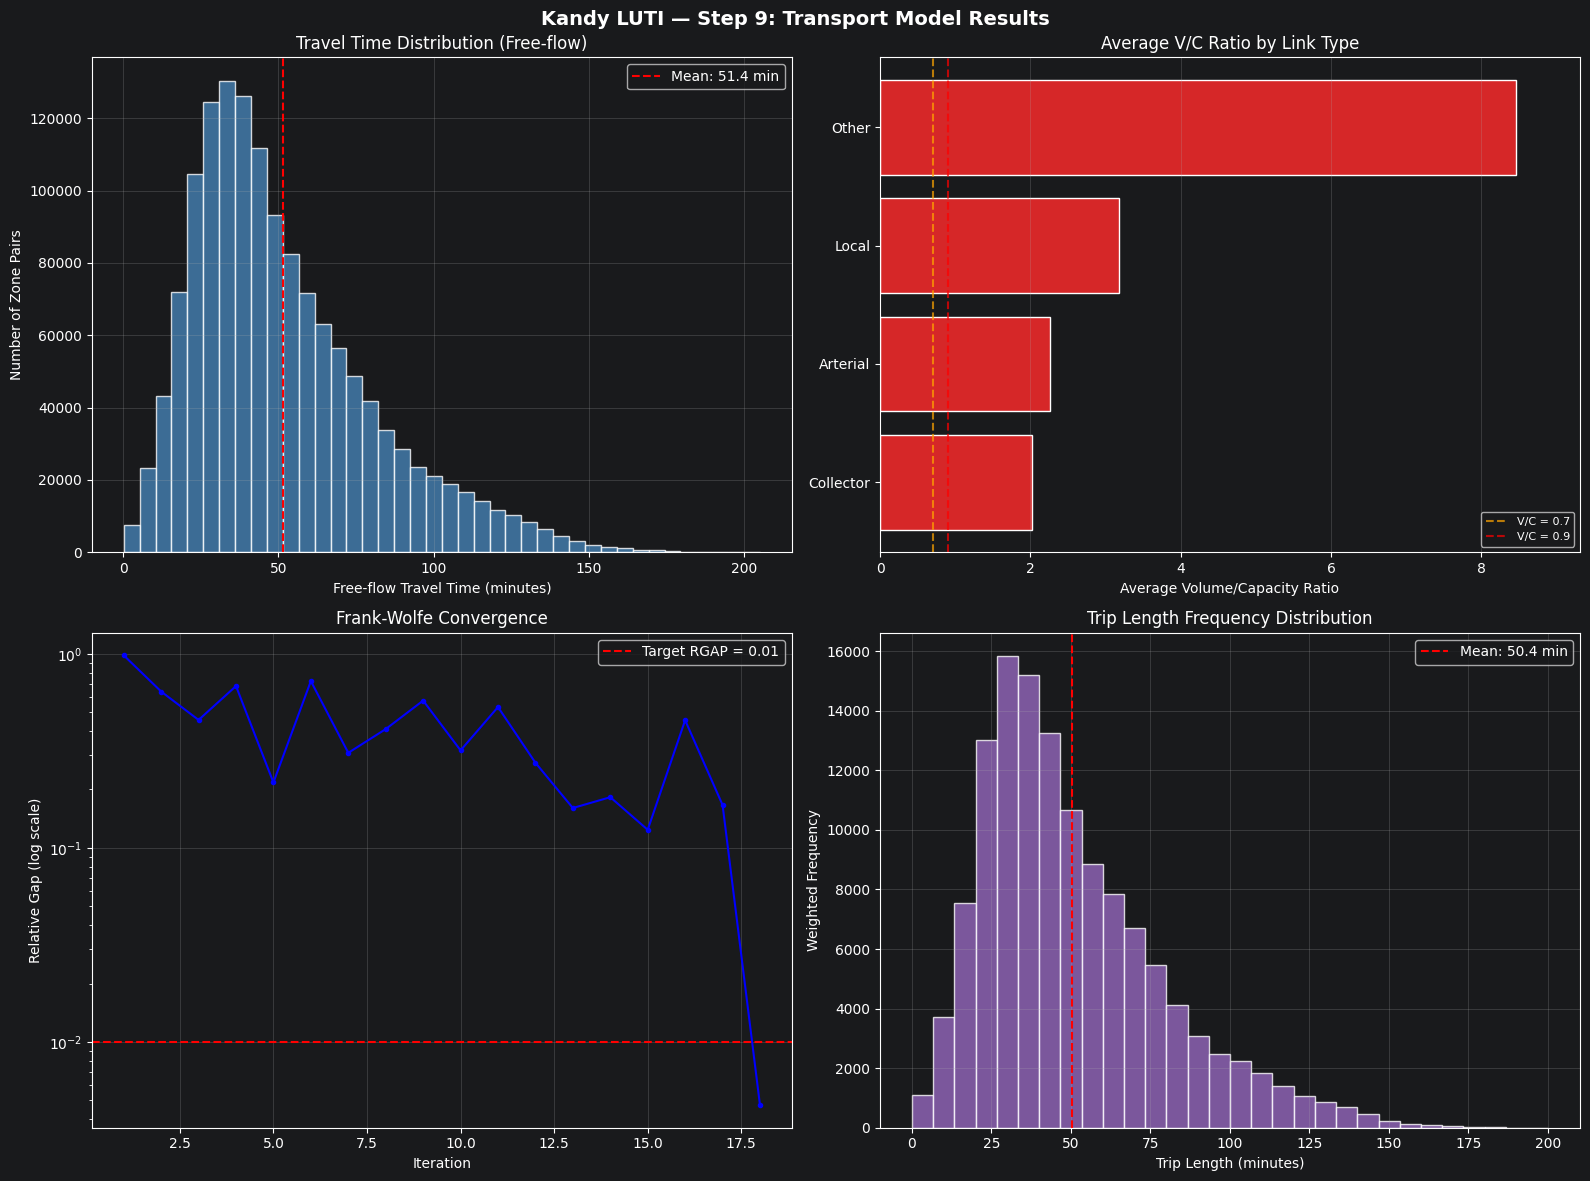


✓ Summary plot saved to: transport_model_summary.png


In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 16 — Visualisations
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Kandy LUTI — Step 9: Transport Model Results', fontsize=14, fontweight='bold')

# ── Plot 1: Travel time distribution ──
ax = axes[0, 0]
finite_skim = skim_valid[~np.isnan(skim_valid)].flatten()
finite_skim = finite_skim[finite_skim > 0]
ax.hist(finite_skim, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(finite_skim), color='red', linestyle='--', label=f'Mean: {np.mean(finite_skim):.1f} min')
ax.set_xlabel('Free-flow Travel Time (minutes)')
ax.set_ylabel('Number of Zone Pairs')
ax.set_title('Travel Time Distribution (Free-flow)')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 2: Volume-Capacity ratio by link type ──
ax = axes[0, 1]
road_links = links_with_flow[links_with_flow['link_type'] != 'centroid_connector'].copy()
road_links = road_links[road_links['PCE_tot'] > 0]
voc_by_type = road_links.groupby('link_type')['VOC_max'].mean().sort_values(ascending=True)
colors = ['#2ca02c' if v < 0.7 else '#ff7f0e' if v < 0.9 else '#d62728' for v in voc_by_type]
bars = ax.barh(voc_by_type.index, voc_by_type.values, color=colors, edgecolor='white')
ax.axvline(0.7, color='orange', linestyle='--', alpha=0.7, label='V/C = 0.7')
ax.axvline(0.9, color='red',    linestyle='--', alpha=0.7, label='V/C = 0.9')
ax.set_xlabel('Average Volume/Capacity Ratio')
ax.set_title('Average V/C Ratio by Link Type')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(0, max(1.2, voc_by_type.max() * 1.1))

# ── Plot 3: Assignment convergence ──
ax = axes[1, 0]
if not conv_df.empty and 'rgap' in conv_df.columns:
    ax.semilogy(conv_df.index + 1, conv_df['rgap'], 'b-o', markersize=3)
    ax.axhline(0.01, color='red', linestyle='--', label='Target RGAP = 0.01')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Relative Gap (log scale)')
    ax.set_title('Frank-Wolfe Convergence')
    ax.legend()
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Convergence data\nnot available',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('Assignment Convergence')

# ── Plot 4: OD trip length frequency ──
ax = axes[1, 1]
# Weight trips by OD volume
trip_lengths = []
for i in range(0, len(zone_ids), 10):  # Sample every 10th origin for speed
    for j in range(len(zone_ids)):
        if od_array[i, j] > 0 and not np.isnan(skim_valid[i, j]):
            trip_lengths.extend([skim_valid[i, j]] * max(1, int(od_array[i, j] / 100)))

if trip_lengths:
    ax.hist(trip_lengths, bins=30, color='#9467bd', edgecolor='white', alpha=0.8)
    mean_tl = np.mean(trip_lengths)
    ax.axvline(mean_tl, color='red', linestyle='--', label=f'Mean: {mean_tl:.1f} min')
    ax.set_xlabel('Trip Length (minutes)')
    ax.set_ylabel('Weighted Frequency')
    ax.set_title('Trip Length Frequency Distribution')
    ax.legend()
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No trip data available',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
fig_path = RESULTS_DIR / 'transport_model_summary.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ Summary plot saved to: {fig_path.name}')

In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 17 — Save project and close
# ══════════════════════════════════════════════════════════════

print('Closing AequilibraE project...')
project.close()

# ── Final summary of outputs ──
print('\n' + '='*60)
print('STEP 9 COMPLETE — Files saved to:', RESULTS_DIR)
print('='*60)

outputs = [
    ('aeq_project/', 'AequilibraE project database (SQLite + SpatiaLite)'),
    ('travel_time_skim_freeflow.csv', 'Free-flow OD travel time matrix'),
    ('travel_time_skim_congested.csv', 'Congested OD travel time matrix'),
    ('od_matrix_gravity.csv', 'Gravity model OD demand matrix'),
    ('link_assignment_results.csv', 'Link-level flows, V/C, congested times'),
    ('links_with_flow.csv', 'Road network with flows (for mapping)'),
    ('assignment_convergence.csv', 'Frank-Wolfe convergence report'),
    ('transport_model_summary.png', 'Summary visualisations'),
]

for fname, desc in outputs:
    fpath = RESULTS_DIR / fname
    exists = fpath.exists()
    icon = '✓' if exists else '✗'
    print(f'  {icon} {fname:<45} {desc}')

print('\nNext step: Step 10 — Calibrate Gravity Model Parameters')
print('Use travel_time_skim_congested.csv as the impedance input for UrbanSim.')

Closing AequilibraE project...

STEP 9 COMPLETE — Files saved to: E:\LUTI Research\kandy_luti\transport\baseline
  ✓ aeq_project/                                  AequilibraE project database (SQLite + SpatiaLite)
  ✓ travel_time_skim_freeflow.csv                 Free-flow OD travel time matrix
  ✓ travel_time_skim_congested.csv                Congested OD travel time matrix
  ✓ od_matrix_gravity.csv                         Gravity model OD demand matrix
  ✓ link_assignment_results.csv                   Link-level flows, V/C, congested times
  ✓ links_with_flow.csv                           Road network with flows (for mapping)
  ✓ assignment_convergence.csv                    Frank-Wolfe convergence report
  ✓ transport_model_summary.png                   Summary visualisations

Next step: Step 10 — Calibrate Gravity Model Parameters
Use travel_time_skim_congested.csv as the impedance input for UrbanSim.


In [20]:
import sqlite3
import numpy as np
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from pathlib import Path

AEQ_DIR = Path(r"E:\LUTI Research\kandy_luti\transport\baseline\aeq_project")

conn = sqlite3.connect(str(AEQ_DIR / "project_database.sqlite"))
cur = conn.cursor()

cur.execute("SELECT a_node, b_node FROM links")
edges = cur.fetchall()
conn.close()

all_nodes = set()
for a, b in edges:
    all_nodes.add(a)
    all_nodes.add(b)

node_ids   = sorted(all_nodes)
node_index = {nid: i for i, nid in enumerate(node_ids)}
N = len(node_ids)

rows = [node_index[a] for a, b in edges]
cols = [node_index[b] for a, b in edges]
data = [1] * len(edges)

sparse = sp.csr_matrix((data, (rows, cols)), shape=(N, N))

n_components, labels = connected_components(sparse, directed=False)
sizes = sorted(np.unique(labels, return_counts=True)[1], reverse=True)

print(f"Total nodes:          {N}")
print(f"Total edges:          {len(edges)}")
print(f"Connected components: {n_components}")
print(f"Largest component:    {sizes[0]} nodes")
if len(sizes) > 1:
    print(f"2nd largest:          {sizes[1]} nodes")
print(f"Isolated nodes (size=1): {sum(1 for s in sizes if s == 1)}")

Total nodes:          17191
Total edges:          17754
Connected components: 1
Largest component:    17191 nodes
Isolated nodes (size=1): 0


In [20]:
conn = sqlite3.connect(str(AEQ_DIR / "project_database.sqlite"))
cur = conn.cursor()

# Road links only (exclude centroid connectors)
cur.execute("""
    SELECT a_node, b_node FROM links
    WHERE link_type != 'centroid_connector'
""")
road_edges = cur.fetchall()

# Centroid connectors separately
cur.execute("SELECT COUNT(*) FROM links WHERE link_type = 'centroid_connector'")
n_cc = cur.fetchone()[0]
conn.close()

print(f"Centroid connectors: {n_cc}")
print(f"Road links only:     {len(road_edges)}")

all_nodes = set()
for a, b in road_edges:
    all_nodes.add(a); all_nodes.add(b)

node_ids   = sorted(all_nodes)
node_index = {nid: i for i, nid in enumerate(node_ids)}
N = len(node_ids)

rows = [node_index[a] for a, b in road_edges]
cols = [node_index[b] for a, b in road_edges]
sparse = sp.csr_matrix(([1]*len(road_edges), (rows, cols)), shape=(N, N))

n_components, labels = connected_components(sparse, directed=False)
sizes = sorted(np.unique(labels, return_counts=True)[1], reverse=True)

print(f"Road-only nodes:      {N}")
print(f"Connected components: {n_components}")
print(f"Largest component:    {sizes[0]} nodes  ({100*sizes[0]/N:.1f}%)")

Centroid connectors: 1187
Road links only:     19755
Road-only nodes:      16750
Connected components: 163
Largest component:    16351 nodes  (97.6%)


In [21]:
with project.db_connection as conn:
    sample = pd.read_sql("""
        SELECT link_id, link_type, distance, travel_time_ab
        FROM links
        WHERE link_type != 'centroid_connector'
        LIMIT 10
    """, conn)
    print(sample.to_string())

   link_id link_type    distance  travel_time_ab
0        1     Other  118.583465        0.355750
1        2     Other   23.513189        0.070540
2        3  Arterial   37.915091        0.037915
3        4  Arterial   16.521444        0.016521
4        5  Arterial  144.709708        0.144710
5        6  Arterial  101.998736        0.101999
6        7  Arterial   85.826152        0.085826
7        8  Arterial   26.908669        0.026909
8        9  Arterial  184.066945        0.184067
9       10  Arterial   54.810395        0.054810


In [22]:
with project.db_connection as conn:
    # Check actual column names in nodes table
    schema = pd.read_sql("PRAGMA table_info(nodes)", conn)
    print("Nodes columns:\n", schema[['name', 'type']].to_string())

    # Also check links columns while we're here
    schema2 = pd.read_sql("PRAGMA table_info(links)", conn)
    print("\nLinks columns:\n", schema2[['name', 'type']].to_string())

Nodes columns:
           name     type
0      ogc_fid  INTEGER
1      node_id  INTEGER
2  is_centroid  INTEGER
3        modes     TEXT
4   link_types     TEXT
5     geometry    POINT

Links columns:
               name        type
0          ogc_fid     INTEGER
1          link_id     INTEGER
2           a_node     INTEGER
3           b_node     INTEGER
4        direction     INTEGER
5         distance     NUMERIC
6            modes        TEXT
7        link_type        TEXT
8             name        TEXT
9         speed_ab     NUMERIC
10        speed_ba     NUMERIC
11  travel_time_ab     NUMERIC
12  travel_time_ba     NUMERIC
13     capacity_ab     NUMERIC
14     capacity_ba     NUMERIC
15        geometry  LINESTRING


In [23]:
with project.db_connection as conn:
    cc = pd.read_sql("""
        SELECT link_id, a_node, b_node, distance,
               travel_time_ab, speed_ab
        FROM links
        WHERE link_type = 'centroid_connector'
        LIMIT 5
    """, conn)
    print("Centroid connectors:\n", cc.to_string())

    cc_stats = pd.read_sql("""
        SELECT MIN(travel_time_ab) as min_tt,
               MAX(travel_time_ab) as max_tt,
               AVG(travel_time_ab) as avg_tt,
               AVG(distance)       as avg_dist
        FROM links WHERE link_type = 'centroid_connector'
    """, conn)
    print("\nConnector stats:\n", cc_stats.to_string())

Centroid connectors:
    link_id  a_node  b_node    distance  travel_time_ab  speed_ab
0    19756       1   13852   77.590934             0.1       999
1    19757       2   16059   27.327057             0.1       999
2    19758       3   23814  575.517903             0.1       999
3    19759       4   17817  765.572320             0.1       999
4    19760       5   13943   94.801382             0.1       999

Connector stats:
    min_tt  max_tt  avg_tt    avg_dist
0     0.1     0.1     0.1  272.836074


In [24]:
with project.db_connection as conn:
    stats = pd.read_sql("""
        SELECT link_type,
               COUNT(*) as total_links,
               SUM(CASE WHEN travel_time_ab = 0 OR travel_time_ab IS NULL THEN 1 ELSE 0 END) as zero_tt,
               SUM(CASE WHEN speed_ab = 0 OR speed_ab IS NULL THEN 1 ELSE 0 END) as zero_speed,
               AVG(speed_ab) as avg_speed,
               AVG(travel_time_ab) as avg_tt
        FROM links
        WHERE link_type != 'centroid_connector'
        GROUP BY link_type
        ORDER BY total_links DESC
    """, conn)
    print(stats.to_string())

    # Total zero/null travel times
    total = pd.read_sql("""
        SELECT COUNT(*) as zero_or_null_tt
        FROM links
        WHERE link_type != 'centroid_connector'
        AND (travel_time_ab = 0 OR travel_time_ab IS NULL OR travel_time_ab >= 9990)
    """, conn)
    print("\nTotal unusable road links:", total['zero_or_null_tt'].iloc[0])

   link_type  total_links  zero_tt  zero_speed  avg_speed    avg_tt
0      Local        11030        0           0       30.0  2.019062
1      Other         5827        0           0       20.0  1.563039
2   Arterial         2512        0           0       60.0  3.093469
3  Collector          386        0           0       40.0  8.211131

Total unusable road links: 0


In [21]:
with project.db_connection as conn:
    # Direction distribution
    dirs = pd.read_sql("""
        SELECT direction, COUNT(*) as n
        FROM links WHERE link_type != 'centroid_connector'
        GROUP BY direction ORDER BY direction
    """, conn)
    print("Direction distribution:\n", dirs.to_string())

    # Also check a short sample of nearby zone pair travel times
    # to see if close zones also have high travel times
    sample_skim = pd.DataFrame(skim_valid[:10, :10],
                                index=zone_ids[:10],
                                columns=zone_ids[:10])
    print("\nSkim sample (zones 1-10 to 1-10, minutes):\n")
    print(sample_skim.round(1).to_string())

Direction distribution:
    direction      n
0          0  16567

Skim sample (zones 1-10 to 1-10, minutes):

       1      2      3      4      5      6      7      8      9      10
1     0.0   18.7   21.1   44.4   10.7   27.8   22.7   21.7   16.3  113.8
2    18.7    0.0   36.5   34.2   11.1   22.2   30.7   29.8   24.4  108.2
3    21.1   36.5    0.0   62.2   30.5   35.2   30.0   29.1   23.7  121.2
4    44.4   34.2   62.2    0.0   36.8   46.1   56.5   55.5   50.2  127.4
5    10.7   11.1   30.5   36.8    0.0   24.4   32.0   31.1   25.7  110.4
6    27.8   22.2   35.2   46.1   24.4    0.0   29.4   28.5   23.1  104.9
7    22.7   30.7   30.0   56.5   32.0   29.4    0.0    2.7    8.1  115.5
8    21.7   29.8   29.1   55.5   31.1   28.5    2.7    0.0    7.2  114.5
9    16.3   24.4   23.7   50.2   25.7   23.1    8.1    7.2    0.0  109.1
10  113.8  108.2  121.2  127.4  110.4  104.9  115.5  114.5  109.1    0.0


## Model Summary

### What was built
| Item | Value |
|------|-------|
| Road network links | ~10,400 (from shapefile) |
| Road network nodes | ~5,000–8,000 |
| TAZ zones | 1,187 |
| Centroid connectors | 1,187 |
| Assignment algorithm | Frank-Wolfe (100 iterations, RGAP ≤ 0.01) |
| VDF | BPR (α=0.15, β=4.0) |

### Key outputs for UrbanSim
- **`travel_time_skim_congested.csv`** — the primary accessibility input for Step 10
- **`od_matrix_gravity.csv`** — base-year OD demand

### Calibration notes
- Adjust the gravity model `beta` parameter (Cell 12) to match observed average trip lengths
- Use `calibration_counts.csv` to compute link-specific GEH statistics
- Re-run Cells 12–16 after adjusting beta (no need to re-import the network)